# 01 - Exploração e tratamento dos dados

Base: **Telco Customer Churn** (IBM, pública), com ~7 mil clientes de uma operadora e a coluna `Churn` (o cliente cancelou? Yes/No).
Esse é o alvo que o modelo vai aprender a prever. Nesta etapa: entender os dados, achar problemas de qualidade e decidir como tratá-los.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/telco_churn.csv')
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Tipos e valores faltantes

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

`TotalCharges` deveria ser numérica, mas veio como texto. Isso costuma indicar valores em branco escondidos como `" "`.
Convertendo com `errors='coerce'`, o que não for número vira `NaN` e aparece na contagem.

In [3]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
faltantes = df[df['TotalCharges'].isna()]
print('Faltantes em TotalCharges:', len(faltantes))
faltantes[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

Faltantes em TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


**Decisão:** todos os faltantes têm `tenure = 0` (clientes que acabaram de entrar e ainda não pagaram nenhuma fatura).
Como ainda não existe histórico de pagamento, essas 11 linhas (0,16% da base) foram **removidas**. Preencher com a média inventaria um valor pago que não existe.

In [4]:
df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)
print(df.shape, '| faltantes restantes:', df.isna().sum().sum())

(7032, 21) | faltantes restantes: 0


## 2. Quanto churn existe? (balanceamento do alvo)

Churn
No     73.4
Yes    26.6
Name: proportion, dtype: float64


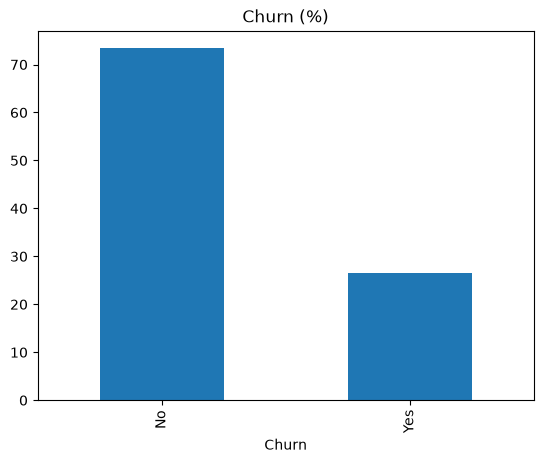

In [5]:
taxa = df['Churn'].value_counts(normalize=True).mul(100).round(1)
print(taxa)
taxa.plot.bar(title='Churn (%)'); plt.show()

A base é **desbalanceada** (~26% de churn). Por isso a acurácia sozinha engana: um modelo que chuta "ninguém cancela" já acerta ~74%.
Na etapa de modelagem vamos olhar **recall** (quantos cancelamentos reais o modelo pega), **precisão** e **AUC**.

## 3. Outliers nas variáveis numéricas (método IQR)

tenure: 0 outliers pelo IQR
MonthlyCharges: 0 outliers pelo IQR
TotalCharges: 0 outliers pelo IQR


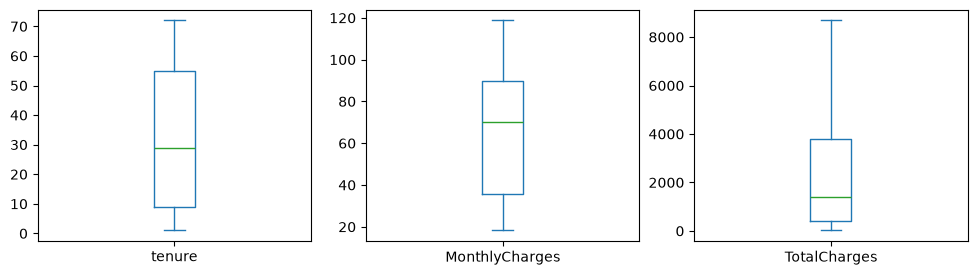

In [6]:
num = ['tenure', 'MonthlyCharges', 'TotalCharges']
for c in num:
    q1, q3 = df[c].quantile([.25, .75]); iqr = q3 - q1
    fora = df[(df[c] < q1 - 1.5 * iqr) | (df[c] > q3 + 1.5 * iqr)]
    print(f'{c}: {len(fora)} outliers pelo IQR')
df[num].plot.box(subplots=True, layout=(1, 3), figsize=(12, 3)); plt.show()

## 4. O que parece influenciar o churn?

In [7]:
for c in ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']:
    print((df.groupby(c)['Churn'].apply(lambda s: (s == 'Yes').mean() * 100)).round(1).sort_values(ascending=False), '\n')

Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64 

InternetService
Fiber optic    41.9
DSL            19.0
No              7.4
Name: Churn, dtype: float64 

PaymentMethod
Electronic check             45.3
Mailed check                 19.2
Bank transfer (automatic)    16.7
Credit card (automatic)      15.3
Name: Churn, dtype: float64 

TechSupport
No                     41.6
Yes                    15.2
No internet service     7.4
Name: Churn, dtype: float64 



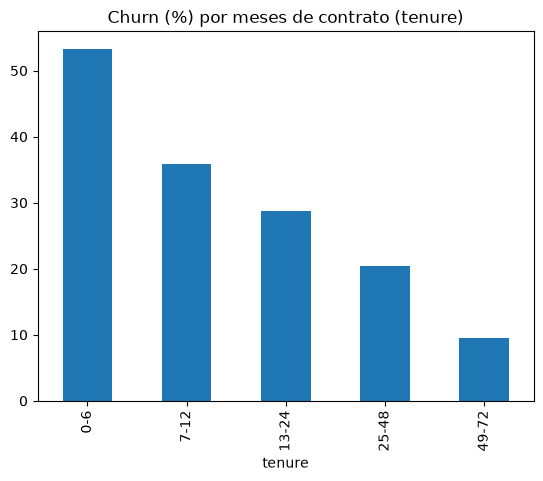

In [8]:
faixas = pd.cut(df['tenure'], [-1, 6, 12, 24, 48, 72], labels=['0-6', '7-12', '13-24', '25-48', '49-72'])
(df.groupby(faixas, observed=True)['Churn'].apply(lambda s: (s == 'Yes').mean() * 100)).round(1).plot.bar(title='Churn (%) por meses de contrato (tenure)'); plt.show()

## 5. Base tratada para a modelagem

In [9]:
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
df.to_csv('../data/telco_tratada.csv', index=False)
df.shape

(7032, 21)